In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [2]:
# LOAD DATA

file_path =  "C:/Medicare Physician & Other Practitioners - by Provider/2023/MUP_PHY_R25_P05_V20_D23_Prov.csv"

df = pd.read_csv(file_path, low_memory=False)

print(df.head())
print(df.shape)
print(df.columns)

   Rndrng_NPI Rndrng_Prvdr_Last_Org_Name Rndrng_Prvdr_First_Name  \
0  1003000126                  Enkeshafi                 Ardalan   
1  1003000134                     Cibull                  Thomas   
2  1003000142                     Khalil                  Rashid   
3  1003000423                    Velotta                Jennifer   
4  1003000480                  Rothchild                   Kevin   

  Rndrng_Prvdr_MI Rndrng_Prvdr_Crdntls Rndrng_Prvdr_Ent_Cd  \
0             NaN                 M.D.                   I   
1               L                 M.D.                   I   
2             NaN                 M.D.                   I   
3               A                 M.D.                   I   
4               B                   MD                   I   

             Rndrng_Prvdr_St1   Rndrng_Prvdr_St2 Rndrng_Prvdr_City  \
0   6410 Rockledge Dr Ste 304                NaN          Bethesda   
1              2650 Ridge Ave  Evanston Hospital          Evanston   
2  4126 

In [3]:
# CLEAN COLUMN NAMES

df.columns = df.columns.str.strip() ## removing extra spaces

df.rename(columns={
    'Tot_Sbmtd_Chrg': 'submitted_charge',
    'Tot_Mdcr_Alowd_Amt': 'allowed_amount'
}, inplace=True)

print(df[['Rndrng_NPI', 'Rndrng_Prvdr_Type', 'submitted_charge', 'allowed_amount']].head())

   Rndrng_NPI        Rndrng_Prvdr_Type  submitted_charge  allowed_amount
0  1003000126              Hospitalist         173087.77        78590.79
1  1003000134                Pathology         726858.00       171256.75
2  1003000142           Anesthesiology         451425.00       155879.22
3  1003000423  Obstetrics & Gynecology          13785.00         6388.39
4  1003000480          General Surgery          98271.00        20288.98


In [4]:
# BASIC CLEANING

needed_cols = [
    'Rndrng_NPI',
    'Rndrng_Prvdr_Type',
    'Tot_Srvcs',
    'submitted_charge',
    'allowed_amount'
]

df = df[needed_cols].copy()

for col in ['Tot_Srvcs', 'submitted_charge', 'allowed_amount']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['submitted_charge', 'allowed_amount', 'Tot_Srvcs'])
df = df[df['allowed_amount'] > 0]

print(df.shape)
print(df.isnull().sum())

(1259343, 5)
Rndrng_NPI           0
Rndrng_Prvdr_Type    0
Tot_Srvcs            0
submitted_charge     0
allowed_amount       0
dtype: int64


In [5]:
# CREATE BASIC BILLING FEATURES

df['charge_diff'] = df['submitted_charge'] - df['allowed_amount']
df['charge_ratio'] = df['submitted_charge'] / df['allowed_amount']

print(df[['submitted_charge', 'allowed_amount', 'charge_diff', 'charge_ratio']].head())
print(df[['charge_diff', 'charge_ratio']].describe())

   submitted_charge  allowed_amount  charge_diff  charge_ratio
0         173087.77        78590.79     94496.98      2.202393
1         726858.00       171256.75    555601.25      4.244259
2         451425.00       155879.22    295545.78      2.895992
3          13785.00         6388.39      7396.61      2.157821
4          98271.00        20288.98     77982.02      4.843565
        charge_diff  charge_ratio
count  1.259343e+06  1.259343e+06
mean   2.527210e+05  3.847322e+00
std    2.555995e+06  4.135186e+00
min   -3.184400e+02  9.976239e-01
25%    1.657089e+04  1.944458e+00
50%    6.308726e+04  2.733105e+00
75%    1.925272e+05  4.115095e+00
max    1.015741e+09  3.446810e+02


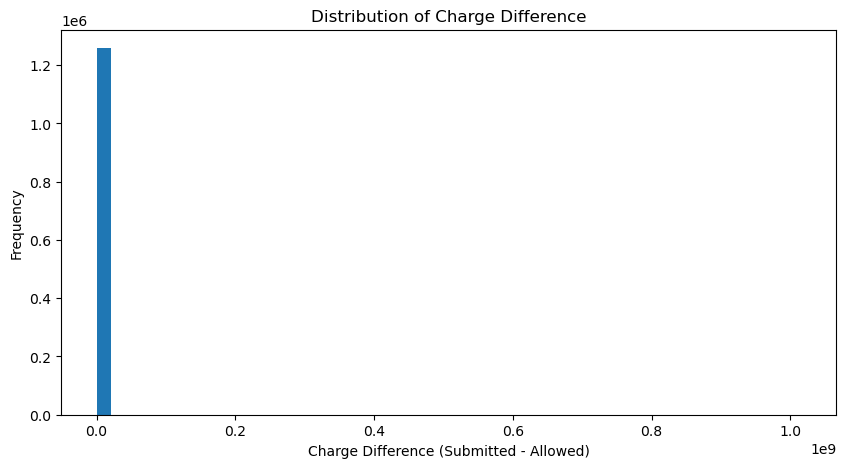

In [6]:
# INITIAL EDA - CHARGE DIFFERENCE

plt.figure(figsize=(10,5))
plt.hist(df['charge_diff'], bins=50)
plt.xlabel("Charge Difference (Submitted - Allowed)")
plt.ylabel("Frequency")
plt.title("Distribution of Charge Difference")
plt.show()

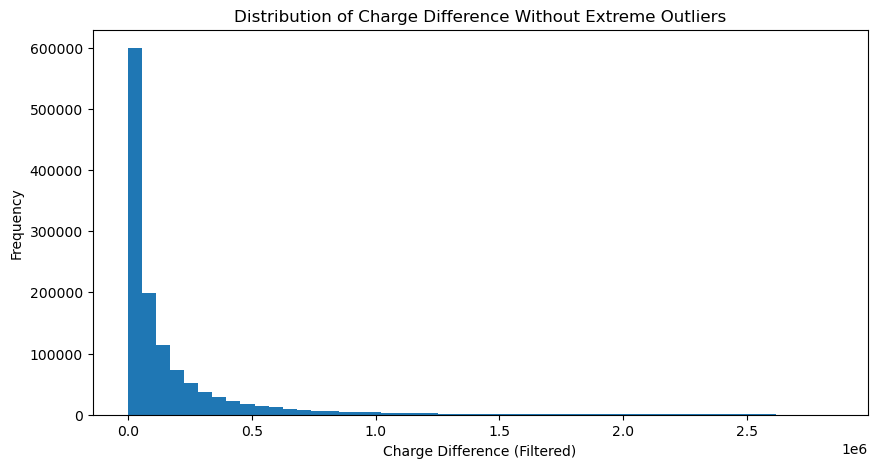

In [7]:
# This is only for visualization because the full distribution has extreme outliers

upper_limit = df['charge_diff'].quantile(0.99)
df_filtered = df[df['charge_diff'] <= upper_limit]

plt.figure(figsize=(10,5))
plt.hist(df_filtered['charge_diff'], bins=50)
plt.xlabel("Charge Difference (Filtered)")
plt.ylabel("Frequency")
plt.title("Distribution of Charge Difference Without Extreme Outliers")
plt.show()

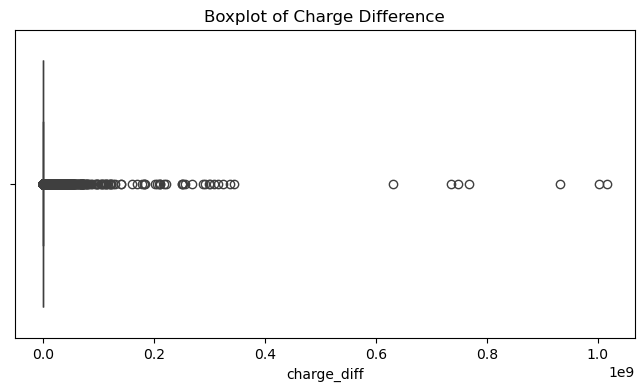

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['charge_diff'])
plt.title("Boxplot of Charge Difference")
plt.show()

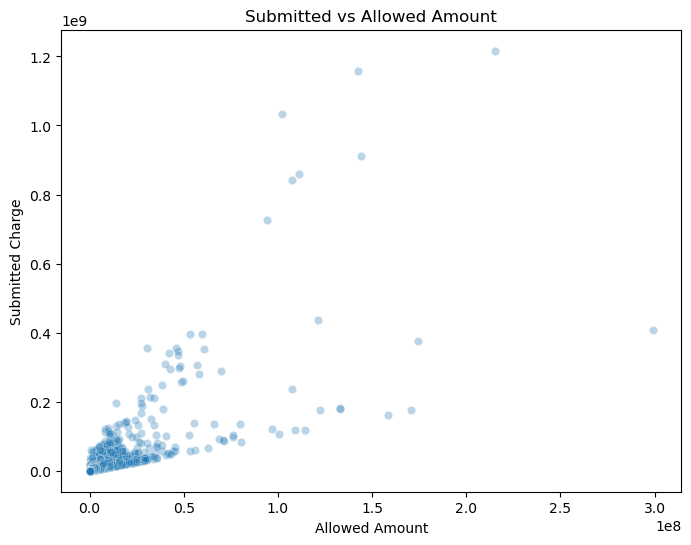

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='allowed_amount',
    y='submitted_charge',
    data=df,
    alpha=0.3
)

plt.title("Submitted vs Allowed Amount")
plt.xlabel("Allowed Amount")
plt.ylabel("Submitted Charge")
plt.show()

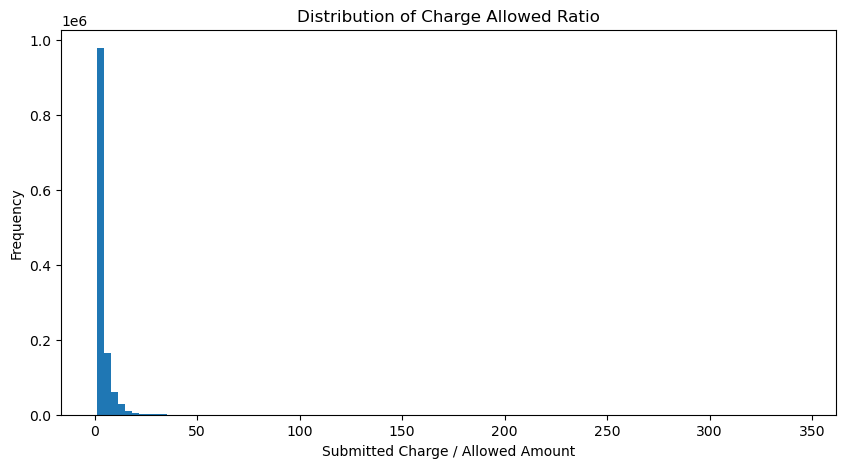

In [10]:
# RATIO DISTRIBUTION

plt.figure(figsize=(10,5))
plt.hist(df['charge_ratio'], bins=100)
plt.title("Distribution of Charge Allowed Ratio")
plt.xlabel("Submitted Charge / Allowed Amount")
plt.ylabel("Frequency")
plt.show()

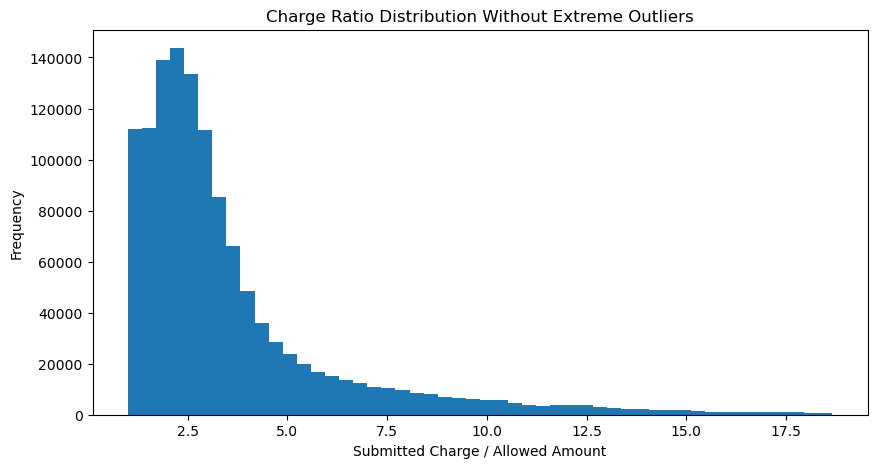

In [11]:
# Filtered ratio view for easier interpretation

ratio_limit = df['charge_ratio'].quantile(0.99)
df_ratio_filtered = df[df['charge_ratio'] <= ratio_limit]

plt.figure(figsize=(10,5))
plt.hist(df_ratio_filtered['charge_ratio'], bins=50)
plt.title("Charge Ratio Distribution Without Extreme Outliers")
plt.xlabel("Submitted Charge / Allowed Amount")
plt.ylabel("Frequency")
plt.show()

In [12]:
'''These visualizations help show how submitted charges, allowed amounts, and charge ratios are distributed.
The goal here is to understand billing patterns before applying provider-level anomaly detection.'''

'These visualizations help show how submitted charges, allowed amounts, and charge ratios are distributed.\nThe goal here is to understand billing patterns before applying provider-level anomaly detection.'

In [13]:
provider_df = df[
    [
        'Rndrng_NPI',
        'Rndrng_Prvdr_Type',
        'charge_ratio',
        'Tot_Srvcs',
        'submitted_charge',
        'allowed_amount'
    ]
].copy()

provider_df.rename(columns={
    'charge_ratio': 'mean_ratio',
    'Tot_Srvcs': 'total_services',
    'submitted_charge': 'total_submitted',
    'allowed_amount': 'total_allowed'
}, inplace=True)

print(provider_df.head())
print(provider_df.shape)

   Rndrng_NPI        Rndrng_Prvdr_Type  mean_ratio  total_services  \
0  1003000126              Hospitalist    2.202393           814.0   
1  1003000134                Pathology    4.244259          4839.0   
2  1003000142           Anesthesiology    2.895992          1455.0   
3  1003000423  Obstetrics & Gynecology    2.157821           119.0   
4  1003000480          General Surgery    4.843565           124.0   

   total_submitted  total_allowed  
0        173087.77       78590.79  
1        726858.00      171256.75  
2        451425.00      155879.22  
3         13785.00        6388.39  
4         98271.00       20288.98  
(1259343, 6)


In [14]:
# Looking at providers with the highest average charge ratio

top_ratio_providers = provider_df.sort_values(
    by='mean_ratio',
    ascending=False
).head(10)

print(top_ratio_providers[
    [
        'Rndrng_NPI',
        'Rndrng_Prvdr_Type',
        'mean_ratio',
        'total_services',
        'total_submitted',
        'total_allowed'
    ]
])

         Rndrng_NPI                   Rndrng_Prvdr_Type  mean_ratio  \
1078924  1851681498                  Nurse Practitioner  344.681009   
18027    1013345552                 Physician Assistant  329.577687   
325718   1255833281                 Physician Assistant  325.723373   
1072967  1851353270                      Anesthesiology  278.366872   
249128   1194812883                  Emergency Medicine  265.189311   
509387   1407349426                     Family Practice  260.854469   
393086   1316121205  Plastic and Reconstructive Surgery  260.671098   
392390   1316076482                  Emergency Medicine  260.084603   
616545   1487910469                 Physician Assistant  257.223137   
889890   1700808243                  Emergency Medicine  256.233386   

         total_services  total_submitted  total_allowed  
1078924            81.0       2300959.44        6675.62  
18027              22.0        739064.78        2242.46  
325718             20.0        652371.80    

In [15]:
## these are like stronger candidates that needs further investigation

In [16]:
# PEER GROUP Z-SCORE
# Providers should be compared with similar provider types, not the whole dataset.

peer_stats = provider_df.groupby('Rndrng_Prvdr_Type')['mean_ratio'].agg(
    peer_mean='mean',
    peer_std='std'
).reset_index()

provider_df = provider_df.merge(peer_stats, on='Rndrng_Prvdr_Type', how='left')

provider_df['z_score'] = (
    provider_df['mean_ratio'] - provider_df['peer_mean']
) / provider_df['peer_std']

provider_df['z_score'] = provider_df['z_score'].replace([np.inf, -np.inf], np.nan)
provider_df['z_score'] = provider_df['z_score'].fillna(0)

provider_df['z_flag'] = provider_df['z_score'] > 3

print(provider_df[['Rndrng_NPI', 'Rndrng_Prvdr_Type', 'mean_ratio', 'peer_mean', 'z_score', 'z_flag']].head())
print(provider_df['z_flag'].value_counts())

   Rndrng_NPI        Rndrng_Prvdr_Type  mean_ratio  peer_mean   z_score  \
0  1003000126              Hospitalist    2.202393   2.966341 -0.598717   
1  1003000134                Pathology    4.244259   4.748394 -0.214696   
2  1003000142           Anesthesiology    2.895992  10.325829 -1.211455   
3  1003000423  Obstetrics & Gynecology    2.157821   3.050868 -0.599619   
4  1003000480          General Surgery    4.843565   3.964990  0.267879   

   z_flag  
0   False  
1   False  
2   False  
3   False  
4   False  
z_flag
False    1242093
True       17250
Name: count, dtype: int64


In [17]:
provider_df['peer_mean_ratio'] = provider_df.groupby('Rndrng_Prvdr_Type')['mean_ratio'].transform('mean')
provider_df['peer_std_ratio'] = provider_df.groupby('Rndrng_Prvdr_Type')['mean_ratio'].transform('std')

provider_df['peer_z_score'] = (
    (provider_df['mean_ratio'] - provider_df['peer_mean_ratio']) /
    provider_df['peer_std_ratio']
)

provider_df['peer_z_score'] = provider_df['peer_z_score'].replace([np.inf, -np.inf], np.nan)
provider_df['peer_z_score'] = provider_df['peer_z_score'].fillna(0)

provider_df['zscore_anomaly'] = provider_df['peer_z_score'] > 3

In [18]:
# Top providers based on z-score
## z score shows how far they are from their group
top_zscore_providers = provider_df.sort_values(
    by='z_score',
    ascending=False
).head(10)

print(top_zscore_providers[
    ['Rndrng_NPI', 'Rndrng_Prvdr_Type', 'mean_ratio', 'peer_mean', 'z_score']
])

         Rndrng_NPI             Rndrng_Prvdr_Type  mean_ratio  peer_mean  \
1063050  1841398922                  Chiropractic  241.863664   1.605726   
509387   1407349426               Family Practice  260.854469   2.535601   
437582   1346648722               Family Practice  245.261184   2.535601   
1078924  1851681498            Nurse Practitioner  344.681009   3.191896   
1233511  1972973428  Mass Immunizer Roster Biller   82.057826   1.164089   
505532   1407092620               Family Practice  168.963407   2.535601   
1194294  1942779665  Mass Immunizer Roster Biller   70.193904   1.164089   
249128   1194812883            Emergency Medicine  265.189311   6.147840   
392390   1316076482            Emergency Medicine  260.084603   6.147840   
889890   1700808243            Emergency Medicine  256.233386   6.147840   

            z_score  
1063050  163.844383  
509387   126.900450  
437582   119.240170  
1078924  118.332273  
1233511   87.399625  
505532    81.758501  
1194294  

In [19]:
''' We ranked providers based on their z-score to identify those who deviate the most from their peer group.
Some providers showed extremely high z-scores, indicating that their billing behavior is significantly different from others in the same specialty.
These providers are strong candidates for further investigation.'''

' We ranked providers based on their z-score to identify those who deviate the most from their peer group.\nSome providers showed extremely high z-scores, indicating that their billing behavior is significantly different from others in the same specialty.\nThese providers are strong candidates for further investigation.'

In [20]:
# ISOLATION FOREST
#  Using this for unsupervised anomaly detection method.

from sklearn.preprocessing import MinMaxScaler

features = [
    'mean_ratio',
    'total_services',
    'total_submitted',
    'total_allowed'
]

model_data = provider_df[features].replace([np.inf, -np.inf], np.nan).dropna()

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(model_data)

iso_model = IsolationForest(
    contamination=0.03, ## assuming 3% of providers as anomalies
    random_state=42
)

iso_predictions = iso_model.fit_predict(X_scaled)

model_data['iso_flag'] = iso_predictions == -1

provider_df['iso_flag'] = False
provider_df.loc[model_data.index, 'iso_flag'] = model_data['iso_flag']

print(provider_df['iso_flag'].value_counts())

iso_flag
False    1221564
True       37779
Name: count, dtype: int64


In [21]:
'''false represents normal provider behavior and true represents anomolies provider behavior'''

'false represents normal provider behavior and true represents anomolies provider behavior'

In [22]:
# COMBINED ANOMALY LOGIC ( combination of z-score and isolation)

provider_df['needs_investigation'] = (
    provider_df['z_flag'] |
    provider_df['iso_flag']
)

print(provider_df['needs_investigation'].value_counts())

needs_investigation
False    1209478
True       49865
Name: count, dtype: int64


In [23]:
'''We combined both anomaly detection methods to create the final suspicious-provider label and then used for ML training'''

'We combined both anomaly detection methods to create the final suspicious-provider label and then used for ML training'

C:\Users\konka\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\konka\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\konka\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\konka\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\konka\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

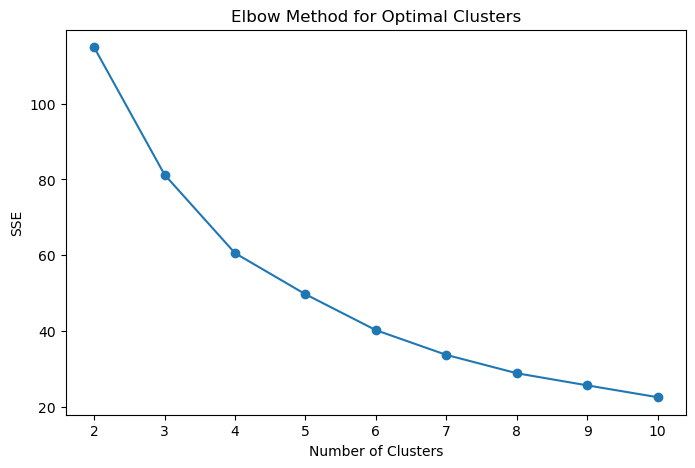

In [24]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# K-MEANS CLUSTERING
# This is used to see whether providers naturally group into different billing patterns.

# REUSING SAME FEATURES FROM ISOLATION FOREST

model_data = provider_df[
    [
        'mean_ratio', 
        'total_services',
        'total_submitted',
        'total_allowed'
    ]
].replace([np.inf, -np.inf], np.nan).dropna()

# STEP 1: MIN-MAX SCALING

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(model_data)


# STEP 2: ELBOW METHOD (SSE)

sse = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    sse.append(kmeans.inertia_)

# STEP 3: ELBOW PLOT

plt.figure(figsize=(8,5))

plt.plot(range(2,11), sse, marker='o')

plt.title('Elbow Method for Optimal Clusters')

plt.xlabel('Number of Clusters')

plt.ylabel('SSE')

plt.show()

In [25]:
# FINAL KMEANS MODEL

optimal_clusters = 4

kmeans = KMeans(
    n_clusters=optimal_clusters,
    random_state=42,
    n_init=10
)

provider_df['cluster'] = kmeans.fit_predict(X_scaled)

print(provider_df['cluster'].value_counts())

cluster
0    1068081
2     170111
1      20582
3        569
Name: count, dtype: int64


In [26]:
# CENTROIDS (SCALED VALUES)

scaled_centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=model_data.columns
)

print("Centroids (Scaled Data):")

print(scaled_centroids)

Centroids (Scaled Data):
   mean_ratio  total_services  total_submitted  total_allowed
0    0.004820        0.000129         0.000256       0.000401
1    0.061378        0.000022         0.000606       0.000115
2    0.022802        0.000092         0.000541       0.000270
3    0.267308        0.000014         0.001649       0.000075


In [27]:
# CENTROIDS IN ORIGINAL SCALE

original_centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=model_data.columns
)

print(original_centroids)

   mean_ratio  total_services  total_submitted  total_allowed
0    2.654140     2812.867862     3.114822e+05  120001.530335
1   22.092133      491.440399     7.366806e+05   34444.492394
2    8.834344     2009.105006     6.580109e+05   80921.049913
3   92.866880      310.355009     2.006618e+06   22553.515501


In [28]:
# Cluster summary

cluster_summary = provider_df.groupby('cluster').agg(
    providers=('Rndrng_NPI', 'count'),
    avg_mean_ratio=('mean_ratio', 'mean'),
    avg_z_score=('z_score', 'mean'),
    avg_total_services=('total_services', 'mean'),
    avg_total_submitted=('total_submitted', 'mean'),
    avg_total_allowed=('total_allowed', 'mean')
).reset_index()

print(cluster_summary)

   cluster  providers  avg_mean_ratio  avg_z_score  avg_total_services  \
0        0    1068081        2.654094    -0.183003         2812.903211   
1        1      20582       22.092133     2.661610          491.440399   
2        2     170111        8.834053     0.771741         2008.958656   
3        3        569       92.866880    16.519194          310.355009   

   avg_total_submitted  avg_total_allowed  
0         3.114834e+05      120002.724373  
1         7.366806e+05       34444.492394  
2         6.579708e+05       80917.228637  
3         2.006618e+06       22553.515501  


In [29]:
'''Most providers fell into a normal behavior cluster, while smaller clusters showed more unusual billing patterns.
One very small cluster had extremely large billing and service volumes, making those providers strong anomaly candidates'''

'Most providers fell into a normal behavior cluster, while smaller clusters showed more unusual billing patterns.\nOne very small cluster had extremely large billing and service volumes, making those providers strong anomaly candidates'

C:\Users\konka\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


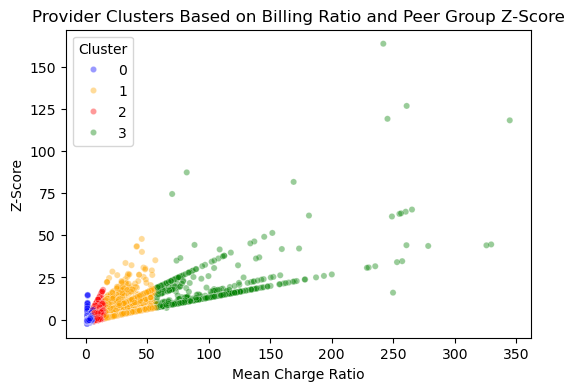

In [30]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=provider_df,
    x='mean_ratio',
    y='z_score',
    hue='cluster',
    palette={
        0: 'blue',
        1: 'orange',
        2: 'red',
        3: 'green'
    },
    alpha=0.4,
    s=20
)

plt.title("Provider Clusters Based on Billing Ratio and Peer Group Z-Score")

plt.xlabel("Mean Charge Ratio")

plt.ylabel("Z-Score")

plt.legend(title="Cluster")

plt.show()

In [31]:
# FINAL SUSPICIOUS PROVIDER FLAG
# A provider is flagged if it has either a high peer group z-score
# or is identified as an anomaly by Isolation Forest.

provider_df['needs_investigation'] = (
    provider_df['z_flag'] |
    provider_df['iso_flag']
)

print(provider_df['needs_investigation'].value_counts())

needs_investigation
False    1209478
True       49865
Name: count, dtype: int64


In [32]:
final_suspicious_providers = provider_df.sort_values(
    by=['needs_investigation', 'z_score', 'mean_ratio'],
    ascending=[False, False, False]
).head(20)

print(top_ratio_providers[
    [
        'Rndrng_NPI',
        'Rndrng_Prvdr_Type',
        'mean_ratio',
        'total_services',
        'total_submitted',
        'total_allowed'
    ]
])

         Rndrng_NPI                   Rndrng_Prvdr_Type  mean_ratio  \
1078924  1851681498                  Nurse Practitioner  344.681009   
18027    1013345552                 Physician Assistant  329.577687   
325718   1255833281                 Physician Assistant  325.723373   
1072967  1851353270                      Anesthesiology  278.366872   
249128   1194812883                  Emergency Medicine  265.189311   
509387   1407349426                     Family Practice  260.854469   
393086   1316121205  Plastic and Reconstructive Surgery  260.671098   
392390   1316076482                  Emergency Medicine  260.084603   
616545   1487910469                 Physician Assistant  257.223137   
889890   1700808243                  Emergency Medicine  256.233386   

         total_services  total_submitted  total_allowed  
1078924            81.0       2300959.44        6675.62  
18027              22.0        739064.78        2242.46  
325718             20.0        652371.80    

In [33]:
'''We ranked providers using a combined anomaly detection approach based on peer-group statistical analysis and machine learning methods.
The providers shown here were flagged through either high peer-group z-scores or Isolation Forest anomaly detection and also demonstrated unusually high billing ratios.
These providers represent the strongest candidates for further investigation.'''

'We ranked providers using a combined anomaly detection approach based on peer-group statistical analysis and machine learning methods.\nThe providers shown here were flagged through either high peer-group z-scores or Isolation Forest anomaly detection and also demonstrated unusually high billing ratios.\nThese providers represent the strongest candidates for further investigation.'

In [34]:
# SAVE RESULTS

provider_df.to_csv("provider_anomaly_results.csv", index=False)
final_suspicious_providers.to_csv("top_suspicious_providers.csv", index=False)
print("Provider anomaly results and suspicious provider files saved successfully.")

Provider anomaly results and suspicious provider files saved successfully.


In [35]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler

# DBSCAN CLUSTERING

# Taking a sample because full dataset is too large

dbscan_df = provider_df.sample(
    n=min(5000, len(provider_df)),
    random_state=42
).copy()

## reducing skew in financial features

dbscan_df['log_submitted'] = np.log1p(
    dbscan_df['total_submitted']
)

dbscan_df['log_allowed'] = np.log1p(
    dbscan_df['total_allowed']
)

# Features for DBSCAN

dbscan_features = dbscan_df[
    [
        'mean_ratio',
        'total_services',
        'log_submitted',
        'log_allowed'
    ]
].replace([np.inf, -np.inf], np.nan).dropna()

# Using Min-Max Scaling as the billing is heavily skewed

scaler = MinMaxScaler()

X_dbscan_scaled = scaler.fit_transform(
    dbscan_features
)

## parameter tuning

eps_values = [0.02, 0.03, 0.05, 0.08, 0.10]

min_samples_values = [5, 10, 20]

print("DBSCAN Parameter Tuning Results\n")

for eps in eps_values:

    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=1
        )

        labels = dbscan.fit_predict(
            X_dbscan_scaled
        )

        outliers = (
            labels == -1
        ).sum()

        clusters = (
            len(set(labels))
            - (1 if -1 in labels else 0)
        )

        print(
            f"eps={eps}, "
            f"min_samples={min_samples}, "
            f"clusters={clusters}, "
            f"outliers={outliers}"
        )

## final selected model after tuning

final_eps = 0.03
final_min_samples = 5

dbscan = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples,
    n_jobs=1
)

final_labels = dbscan.fit_predict(
    X_dbscan_scaled
)

## saving results

provider_df['dbscan_cluster'] = np.nan
provider_df['dbscan_outlier'] = False

provider_df.loc[
    dbscan_features.index,
    'dbscan_cluster'
] = final_labels

provider_df.loc[
    dbscan_features.index,
    'dbscan_outlier'
] = (
    final_labels == -1
)

## savig 

print("\nDBSCAN Outlier Counts")
print(
    provider_df['dbscan_outlier']
    .value_counts()
)

print("\nDBSCAN Cluster Counts")
print(
    pd.Series(final_labels)
    .value_counts()
    .sort_index()
)


# Cluster Summary

dbscan_df['dbscan_cluster'] = final_labels

dbscan_summary = (
    dbscan_df
    .groupby('dbscan_cluster')
    .agg(
        providers=('dbscan_cluster', 'count'),
        avg_mean_ratio=('mean_ratio', 'mean'),
        avg_total_services=('total_services', 'mean'),
        avg_total_submitted=('total_submitted', 'mean'),
        avg_total_allowed=('total_allowed', 'mean')
    )
    .reset_index()
)

print("\nDBSCAN Cluster Summary")
print(dbscan_summary)

DBSCAN Parameter Tuning Results

eps=0.02, min_samples=5, clusters=3, outliers=221
eps=0.02, min_samples=10, clusters=2, outliers=322
eps=0.02, min_samples=20, clusters=1, outliers=561
eps=0.03, min_samples=5, clusters=3, outliers=116
eps=0.03, min_samples=10, clusters=1, outliers=181
eps=0.03, min_samples=20, clusters=1, outliers=261
eps=0.05, min_samples=5, clusters=1, outliers=54
eps=0.05, min_samples=10, clusters=1, outliers=74
eps=0.05, min_samples=20, clusters=1, outliers=108
eps=0.08, min_samples=5, clusters=1, outliers=22
eps=0.08, min_samples=10, clusters=1, outliers=29
eps=0.08, min_samples=20, clusters=1, outliers=48
eps=0.1, min_samples=5, clusters=1, outliers=22
eps=0.1, min_samples=10, clusters=1, outliers=22
eps=0.1, min_samples=20, clusters=1, outliers=29

DBSCAN Outlier Counts
dbscan_outlier
False    1259227
True         116
Name: count, dtype: int64

DBSCAN Cluster Counts
-1     116
 0    4872
 1       7
 2       5
Name: count, dtype: int64

DBSCAN Cluster Summary
   

In [36]:
''' After applying Min-Max scaling and log transformation to reduce skewness, DBSCAN was tuned using multiple epsilon and minimum sample combinations. 
The final configuration (eps = 0.03, min_samples = 5) identified three clusters and 116 outlier providers.Most providers belonged to a single dense 
cluster representing typical billing behavior, while the outlier group exhibited substantially higher billing ratios and financial activity. 
These providers may represent unusual billing patterns requiring further investigation.'''

' After applying Min-Max scaling and log transformation to reduce skewness, DBSCAN was tuned using multiple epsilon and minimum sample combinations. \nThe final configuration (eps = 0.03, min_samples = 5) identified three clusters and 116 outlier providers.Most providers belonged to a single dense \ncluster representing typical billing behavior, while the outlier group exhibited substantially higher billing ratios and financial activity. \nThese providers may represent unusual billing patterns requiring further investigation.'

In [37]:
# SAVE UPDATED RESULTS AFTER DBSCAN

provider_df.to_csv("provider_anomaly_results.csv", index=False)
print("Updated provider anomaly results saved.")

Updated provider anomaly results saved.


In [38]:
# MACHINE LEARNING

# Load processed provider-level anomaly dataset
df = pd.read_csv("provider_anomaly_results.csv")
print(df['needs_investigation'].value_counts())

print(
    df['needs_investigation']
    .value_counts(normalize=True) * 100
)




needs_investigation
False    1209478
True       49865
Name: count, dtype: int64
needs_investigation
False    96.040396
True      3.959604
Name: proportion, dtype: float64


In [39]:
print(df.head())

   Rndrng_NPI        Rndrng_Prvdr_Type  mean_ratio  total_services  \
0  1003000126              Hospitalist    2.202393           814.0   
1  1003000134                Pathology    4.244259          4839.0   
2  1003000142           Anesthesiology    2.895992          1455.0   
3  1003000423  Obstetrics & Gynecology    2.157821           119.0   
4  1003000480          General Surgery    4.843565           124.0   

   total_submitted  total_allowed  peer_mean  peer_std   z_score  z_flag  \
0        173087.77       78590.79   2.966341  1.275975 -0.598717   False   
1        726858.00      171256.75   4.748394  2.348129 -0.214696   False   
2        451425.00      155879.22  10.325829  6.132988 -1.211455   False   
3         13785.00        6388.39   3.050868  1.489358 -0.599619   False   
4         98271.00       20288.98   3.964990  3.279742  0.267879   False   

   peer_mean_ratio  peer_std_ratio  peer_z_score  zscore_anomaly  iso_flag  \
0         2.966341        1.275975     -0.59

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


# DEFINING FEATURES (X) AND TARGET VARIABLE (Y)

df['needs_investigation'] = df['needs_investigation'].astype(str).str.strip()

df['needs_investigation'] = df['needs_investigation'].map({
    'True': 1,
    'False': 0,
    '1': 1,
    '0': 0
})

df = df.dropna(subset=[
    'mean_ratio',
    'total_services',
    'total_submitted',
    'total_allowed',
    'needs_investigation'
])

X = df[
    [
        'mean_ratio',
        'total_services',
        'total_submitted',
        'total_allowed'
    ]
]

y = df['needs_investigation'].astype(int)

# splitting data for training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

## scaling for logistic regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# LOGISTIC REGRESSION WITH CLASS BALANCING

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

## prediction

y_pred = log_model.predict(
    X_test_scaled
)

## evaluation
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96    362993
           1       0.35      0.89      0.50     14810

    accuracy                           0.93    377803
   macro avg       0.67      0.91      0.73    377803
weighted avg       0.97      0.93      0.94    377803



In [41]:
''' Class balancing was applied to address the highly imbalanced dataset. 
The model achieved a high recall (0.89), successfully identifying most providers requiring investigation, 
but at the cost of lower precision (0.35) and an increase in false positives. 
This tradeoff is common in anomaly detection tasks where capturing suspicious cases is the primary objective.'''

' Class balancing was applied to address the highly imbalanced dataset. \nThe model achieved a high recall (0.89), successfully identifying most providers requiring investigation, \nbut at the cost of lower precision (0.35) and an increase in false positives. \nThis tradeoff is common in anomaly detection tasks where capturing suspicious cases is the primary objective.'

In [42]:
# ==========================================================
# LOGISTIC REGRESSION - TRAINING PERFORMANCE
# ==========================================================

y_train_pred_log = log_model.predict(
    X_train_scaled
)

print("Training Results")

print(
    classification_report(
        y_train,
        y_train_pred_log
    )
)

Training Results
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    846485
           1       0.35      0.89      0.50     35055

    accuracy                           0.93    881540
   macro avg       0.67      0.91      0.73    881540
weighted avg       0.97      0.93      0.94    881540



In [43]:
''' Overfitting Check: The Logistic Regression model produced nearly identical results on both the training and testing datasets. 
This indicates that the model generalized well to unseen data and showed no evidence of overfitting.'''

' Overfitting Check: The Logistic Regression model produced nearly identical results on both the training and testing datasets. \nThis indicates that the model generalized well to unseen data and showed no evidence of overfitting.'

In [44]:
## decision tree model

# create model with depth limit
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

# train it
tree_model.fit(X_train, y_train)

# predict again
y_pred_tree = tree_model.predict(X_test)

# evaluate
print(classification_report(y_test, y_pred_tree))


              precision    recall  f1-score   support

           0       1.00      0.92      0.96    362993
           1       0.32      0.92      0.47     14810

    accuracy                           0.92    377803
   macro avg       0.66      0.92      0.72    377803
weighted avg       0.97      0.92      0.94    377803



In [45]:
'''The balanced Decision Tree model achieved high recall (0.92), successfully detecting most providers requiring investigation.
However, the lower precision (0.32) indicates an increase in false positives. 
This behavior is expected when prioritizing anomaly detection in an imbalanced dataset.'''

'The balanced Decision Tree model achieved high recall (0.92), successfully detecting most providers requiring investigation.\nHowever, the lower precision (0.32) indicates an increase in false positives. \nThis behavior is expected when prioritizing anomaly detection in an imbalanced dataset.'

In [46]:
# ==========================================================
# DECISION TREE - TRAINING PERFORMANCE
# ==========================================================

y_train_pred_tree = tree_model.predict(
    X_train
)

print("Training Results")

print(
    classification_report(
        y_train,
        y_train_pred_tree
    )
)

Training Results
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    846485
           1       0.32      0.93      0.48     35055

    accuracy                           0.92    881540
   macro avg       0.66      0.92      0.72    881540
weighted avg       0.97      0.92      0.94    881540



In [47]:
''' Overfitting Check: The Decision Tree produced very similar training and testing results, 
indicating that the depth limitation (max_depth = 5) successfully prevented overfitting. 
The model generalized well to unseen data while maintaining strong recall for providers requiring investigation.'''

' Overfitting Check: The Decision Tree produced very similar training and testing results, \nindicating that the depth limitation (max_depth = 5) successfully prevented overfitting. \nThe model generalized well to unseen data while maintaining strong recall for providers requiring investigation.'

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# RANDOM FOREST
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# Train model

rf_model.fit(X_train, y_train)

# Predictions

y_pred_rf = rf_model.predict(X_test)

# Evaluation

print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    362993
           1       0.97      0.77      0.86     14810

    accuracy                           0.99    377803
   macro avg       0.98      0.88      0.93    377803
weighted avg       0.99      0.99      0.99    377803



In [49]:
''' The balanced Random Forest model provided the best overall performance, achieving high precision (0.97) and a strong F1-score (0.86). 
While recall was slightly lower than other models,
it produced far fewer false positives and maintained excellent anomaly detection capability.'''

' The balanced Random Forest model provided the best overall performance, achieving high precision (0.97) and a strong F1-score (0.86). \nWhile recall was slightly lower than other models,\nit produced far fewer false positives and maintained excellent anomaly detection capability.'

In [50]:
# ==========================================================
# RANDOM FOREST - TRAINING PERFORMANCE
# ==========================================================

y_train_pred_rf = rf_model.predict(
    X_train
)

print("Training Results")

print(
    classification_report(
        y_train,
        y_train_pred_rf
    )
)

Training Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    846485
           1       1.00      1.00      1.00     35055

    accuracy                           1.00    881540
   macro avg       1.00      1.00      1.00    881540
weighted avg       1.00      1.00      1.00    881540



In [51]:
''' Overfitting Check: The Random Forest model achieved perfect performance on the training dataset but lower performance on the testing dataset, 
indicating overfitting. Although the model generalized reasonably well, 
the gap between training and testing performance suggests that additional hyperparameter tuning may help improve generalization.

SyntaxError: incomplete input (4258892437.py, line 1)

In [ ]:
# ==========================================================
# RANDOM FOREST - HYPERPARAMETER TUNING
# ==========================================================

rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

# Test Predictions
y_pred_rf_tuned = rf_tuned.predict(X_test)

print("Testing Results")

print(
    classification_report(
        y_test,
        y_pred_rf_tuned
    )
)

In [ ]:
# ==========================================================
# RANDOM FOREST TUNED - TRAINING PERFORMANCE
# ==========================================================

y_train_pred_rf_tuned = rf_tuned.predict(
    X_train
)

print("Training Results")

print(
    classification_report(
        y_train,
        y_train_pred_rf_tuned
    )
)

In [ ]:
''' Hyperparameter tuning successfully reduced overfitting but resulted in a substantial decrease in overall predictive performance. 
Therefore, the original Random Forest model was retained as the final model despite exhibiting some degree of overfitting.'''

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=(len(y_train[y_train == 0]) / len(y_train[y_train == 1]))
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

In [ ]:
''' The balanced XGBoost model achieved the highest recall (0.95), detecting most providers requiring investigation. 
However, its lower precision (0.35) indicates an increase in false positives. 
This tradeoff is common when prioritizing anomaly detection in highly imbalanced datasets.'''

In [ ]:
# ==========================================================
# XGBOOST - TRAINING PERFORMANCE
# ==========================================================

y_train_pred_xgb = xgb_model.predict(X_train)

print("Training Results")

print(
    classification_report(
        y_train,
        y_train_pred_xgb
    )
)

In [ ]:
'''The XGBoost model produced very similar training and testing results, indicating strong generalization and no evidence of overfitting.'''

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# ==========================================================
# NAIVE BAYES MODEL
# ==========================================================

nb_model = GaussianNB()

# Train model
nb_model.fit(
    X_train,
    y_train
)

# Test predictions
y_pred_nb = nb_model.predict(
    X_test
)

# Evaluation
print("Testing Results")

print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

In [ ]:
# ==========================================================
# NAIVE BAYES - TRAINING PERFORMANCE
# ==========================================================

y_train_pred_nb = nb_model.predict(
    X_train
)

print("Training Results")

print(
    classification_report(
        y_train,
        y_train_pred_nb
    )
)

In [ ]:
''' Overfitting Check: The Naive Bayes model produced nearly identical training and testing results,
indicating strong generalization and no evidence of overfitting. Although it did not outperform Random Forest,
it achieved a balanced tradeoff between precision and recall and provided the second-highest F1-score among the evaluated supervised models.

In [52]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# ==========================================================
# GRADIENT BOOSTING
# ==========================================================

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

y_pred_gb = gb_model.predict(
    X_test
)

print("Testing Results")

print(
    classification_report(
        y_test,
        y_pred_gb
    )
)

Testing Results
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    362993
           1       0.98      0.75      0.85     14810

    accuracy                           0.99    377803
   macro avg       0.98      0.87      0.92    377803
weighted avg       0.99      0.99      0.99    377803



In [54]:
# ==========================================================
# GRADIENT BOOSTING - TRAINING PERFORMANCE
# ==========================================================

y_train_pred_gb = gb_model.predict(
    X_train
)

print("Training Results")

print(
    classification_report(
        y_train,
        y_train_pred_gb
    )
)

Training Results
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    846485
           1       0.98      0.75      0.85     35055

    accuracy                           0.99    881540
   macro avg       0.99      0.87      0.92    881540
weighted avg       0.99      0.99      0.99    881540



In [ ]:
'''
Gradient Boosting achieved strong performance with a precision of 0.98,
recall of 0.75, and an F1-score of 0.85. The model produced nearly identical
results on both the training and testing datasets, indicating excellent
generalization and no evidence of overfitting. Although its F1-score was
slightly lower than Random Forest (0.86), Gradient Boosting provided a strong
balance between precision and recall and was selected as one of the top-performing
models for ensemble modeling.
'''

In [56]:
## comparing these models

comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'Naive Bayes',
        'Gradient Boosting'
    ],

    'Precision': [
        0.35,
        0.32,
        0.97,
        0.35,
        0.55,
        0.98
    ],

    'Recall': [
        0.89,
        0.92,
        0.77,
        0.95,
        0.67,
        0.75
    ],

    'F1-Score': [
        0.50,
        0.47,
        0.86,
        0.51,
        0.60,
        0.85
    ]
})

print(comparison_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True))

                 Model  Precision  Recall  F1-Score
0        Random Forest       0.97    0.77      0.86
1    Gradient Boosting       0.98    0.75      0.85
2          Naive Bayes       0.55    0.67      0.60
3              XGBoost       0.35    0.95      0.51
4  Logistic Regression       0.35    0.89      0.50
5        Decision Tree       0.32    0.92      0.47


In [ ]:
'''
After addressing class imbalance, multiple supervised learning models were
evaluated for detecting providers requiring investigation. Logistic Regression,
Decision Tree, and XGBoost achieved high recall, making them effective at
identifying suspicious providers, but they generated a larger number of false
positives. Naive Bayes achieved moderate performance with an F1-score of 0.60.
Gradient Boosting achieved strong performance with a precision of 0.98, recall
of 0.75, and an F1-score of 0.85 while showing no evidence of overfitting.
Random Forest achieved the highest overall F1-score (0.86) and maintained a
strong balance between precision and recall. Therefore, Random Forest and
Gradient Boosting were selected as the top-performing models for ensemble
modeling, while Random Forest was chosen as the final standalone model for
detecting anomalous provider billing behavior.
'''

In [ ]:

# Additional Experiment: SMOTE for Class Imbalance Handling


In [ ]:
from imblearn.over_sampling import SMOTE

# ==========================================================
# SMOTE
# ==========================================================

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Training Distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ==========================================================
# RANDOM FOREST + SMOTE
# ==========================================================

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_rf_smote = rf_smote.predict(
    X_test
)

print(
    classification_report(
        y_test,
        y_pred_rf_smote
    )
)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# ==========================================================
# XGBOOST + SMOTE
# ==========================================================

xgb_smote = XGBClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_xgb_smote = xgb_smote.predict(
    X_test
)

print(
    classification_report(
        y_test,
        y_pred_xgb_smote
    )
)

In [ ]:
## APPLYING RANDOM SAMPLING TO THE WORST PERFORMED MODEL

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# ==========================================================
# RANDOM OVERSAMPLING
# ==========================================================

ros = RandomOverSampler(
    random_state=42
)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train,
    y_train
)

print("After Oversampling:")

print(y_train_ros.value_counts())

In [ ]:
# ==========================================================
# DECISION TREE + RANDOM OVERSAMPLING
# ==========================================================

tree_ros = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_ros.fit(
    X_train_ros,
    y_train_ros
)

y_pred_tree_ros = tree_ros.predict(
    X_test
)

print("Testing Results")

print(
    classification_report(
        y_test,
        y_pred_tree_ros
    )
)

In [ ]:
'''
Random oversampling was applied to the Decision Tree model to further address class imbalance.
The training data became fully balanced, with equal numbers of normal and investigation cases.
However, model performance showed only a negligible improvement in F1-score (0.47 to 0.48),
indicating that oversampling did not provide a meaningful benefit beyond the class-balancing
techniques already applied. Therefore, subsequent efforts focused on hyperparameter tuning
and ensemble modeling.
'''

In [61]:
# Ensemble Model (Voting Classifier)

from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report

# ==========================================================
# VOTING ENSEMBLE
# ==========================================================

ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model)
    ],
    voting='hard'
)

ensemble_model.fit(
    X_train,
    y_train
)

y_pred_ensemble = ensemble_model.predict(
    X_test
)

print("Testing Results")

print(
    classification_report(
        y_test,
        y_pred_ensemble
    )
)

Testing Results
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    362993
           1       0.99      0.74      0.85     14810

    accuracy                           0.99    377803
   macro avg       0.99      0.87      0.92    377803
weighted avg       0.99      0.99      0.99    377803



In [63]:
# ==========================================================
# ENSEMBLE MODEL - TRAINING PERFORMANCE
# ==========================================================

y_train_pred_ensemble = ensemble_model.predict(
    X_train
)

print("Training Results")

print(
    classification_report(
        y_train,
        y_train_pred_ensemble
    )
)

Training Results
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    846485
           1       1.00      0.75      0.86     35055

    accuracy                           0.99    881540
   macro avg       0.99      0.88      0.93    881540
weighted avg       0.99      0.99      0.99    881540



In [ ]:
'''
The Voting Ensemble combined Random Forest and Gradient Boosting,
the two strongest-performing supervised learning models in this study.
The ensemble achieved a precision of 0.99, recall of 0.74, and an
F1-score of 0.85. While the ensemble produced the highest precision,
its F1-score was slightly lower than the Random Forest model (0.86).
Therefore, Random Forest remained the strongest overall model for
detecting providers requiring investigation. The ensemble demonstrated
good generalization and showed no significant evidence of overfitting.
'''

In [65]:
final_comparison_df = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Gradient Boosting',
        'Voting Ensemble',
        'Naive Bayes',
        'XGBoost',
        'Logistic Regression',
        'Decision Tree'
    ],

    'Precision': [
        0.97,
        0.98,
        0.99,
        0.55,
        0.35,
        0.35,
        0.32
    ],

    'Recall': [
        0.77,
        0.75,
        0.74,
        0.67,
        0.95,
        0.89,
        0.92
    ],

    'F1-Score': [
        0.86,
        0.85,
        0.85,
        0.60,
        0.51,
        0.50,
        0.47
    ]
})

print(
    final_comparison_df.sort_values(
        by='F1-Score',
        ascending=False
    )
)

                 Model  Precision  Recall  F1-Score
0        Random Forest       0.97    0.77      0.86
1    Gradient Boosting       0.98    0.75      0.85
2      Voting Ensemble       0.99    0.74      0.85
3          Naive Bayes       0.55    0.67      0.60
4              XGBoost       0.35    0.95      0.51
5  Logistic Regression       0.35    0.89      0.50
6        Decision Tree       0.32    0.92      0.47


In [ ]:
'''
Final Conclusion:

Multiple unsupervised and supervised machine learning techniques were evaluated
to identify providers requiring investigation. Random Forest achieved the highest
overall F1-score (0.86), making it the strongest standalone model. Gradient
Boosting achieved similar performance (0.85) while showing no evidence of
overfitting. A Voting Ensemble combining Random Forest and Gradient Boosting
was also evaluated and achieved an F1-score of 0.85 with the highest precision
(0.99). However, because Random Forest achieved the highest overall F1-score,
it was selected as the final model for detecting anomalous provider billing
behavior.
'''